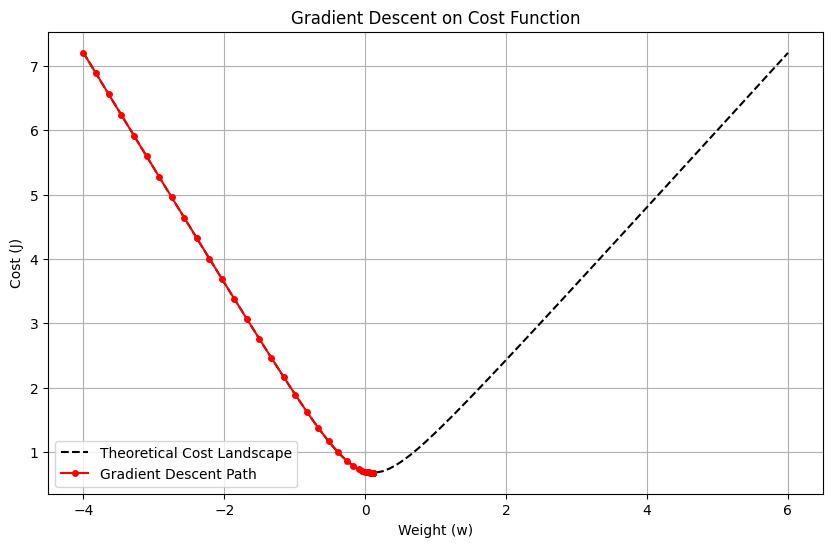

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. DATA
X = np.array([1.0, 2.0, 3.0, 4.0, 5.0])
y = np.array([0.0, 0.0, 0.0, 1.0, 1.0])
m = len(X)

# 2. HELPER: Cost Function
def compute_cost(w_val, X, y):
    # Force w_val to be the right shape for calculation
    z = X * w_val 
    # Sigmoid
    y_hat = 1 / (1 + np.exp(-z))
    
    # Epsilon (Safety)
    epsilon = 1e-15
    y_hat = np.clip(y_hat, epsilon, 1 - epsilon)
    
    # Cost Formula
    cost = -(1/m) * np.sum(y * np.log(y_hat) + (1-y) * np.log(1-y_hat))
    return cost

# --- PART A: GENERATE THE BACKGROUND "U" SHAPE ---
# We calculate the cost for a wide range of weights (e.g., -4 to 6)
# purely for visualization.
possible_weights = np.linspace(-4, 6, 100)
possible_costs = [compute_cost(w, X, y) for w in possible_weights]

# --- PART B: RUN YOUR GRADIENT DESCENT ---
w = -4.0  # Start far to the left to see the travel
lr = 0.1
history_w = []
history_c = []

for i in range(200):
    # Save history
    history_w.append(w)
    history_c.append(compute_cost(w, X, y))
    
    # Update
    z = X * w
    y_hat = 1 / (1 + np.exp(-z))
    dw = (1/m) * np.dot(X, (y_hat - y))
    w = w - lr * dw

# --- PART C: PLOT EVERYTHING ---
plt.figure(figsize=(10, 6))

# 1. Plot the Background "U" Curve (The Landscape)
plt.plot(possible_weights, possible_costs, 'k--', label='Theoretical Cost Landscape')

# 2. Plot the Algorithm's Path (The Red Dots)
plt.plot(history_w, history_c, 'ro-', markersize=4, label='Gradient Descent Path')

# Formatting
plt.title("Gradient Descent on Cost Function")
plt.xlabel("Weight (w)")
plt.ylabel("Cost (J)")
plt.legend()
plt.grid(True)
plt.show()
